In [22]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from typing import Optional, Annotated
from dotenv import load_dotenv, dotenv_values
from IPython.display import Markdown
import os
load_dotenv()

True

In [1]:
# getting all the env variable names
# print(dotenv_values())

In [11]:
class LLMState(BaseModel):
    topic: str
    outline: Optional[str]= None 
    result: Optional[str]= None

In [13]:
def create_topic(state: LLMState) -> LLMState:
    topic= state.topic 
    
    prompt= f'Create an outline for the following topic: {topic}'
    model= ChatGoogleGenerativeAI(model= "gemini-2.0-flash")
    
    outline= model.invoke(prompt).content
    state.outline= outline
    
    return state


def create_content(state: LLMState) -> LLMState:
    
    outline= state.outline 
    topic= state.topic
    
    prompt= f'Write a blog on this topic: {topic}, using the following outline: {outline}'
    model= ChatGoogleGenerativeAI(model= "gemini-2.0-flash")
    
    result= model.invoke(prompt).content
    state.result= result
    return state
    

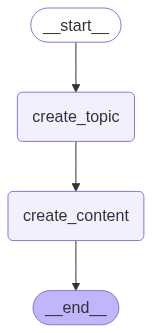

In [15]:
# create graph
graph= StateGraph(LLMState)

# add nodes
graph.add_node('create_topic', create_topic)
graph.add_node('create_content', create_content)

# add edges
graph.add_edge(START, 'create_topic')
graph.add_edge('create_topic', 'create_content')
graph.add_edge('create_content', END)

# compile the graph
workflow= graph.compile()
workflow

In [16]:
initial_state= {'topic': 'State of Electric vehicles in India'}

final_state= workflow.invoke(initial_state)
print(final_state)

{'topic': 'State of Electric vehicles in India', 'outline': 'Okay, here\'s an outline for a report/presentation on the "State of Electric Vehicles in India," covering key areas and potential subtopics:\n\n**I. Introduction**\n\n   *   **A.** Hook/Opening Statement:  (e.g., India\'s commitment to clean mobility, the growing EV market, the challenges and opportunities)\n   *   **B.** Context: Briefly introduce the global shift towards EVs and India\'s position.\n   *   **C.** Importance of EVs in India:  Environmental benefits (reduced pollution, carbon emissions), economic benefits (reduced fuel imports), and social benefits (job creation).\n   *   **D.** Thesis Statement/Overall Goal:  (e.g., This report will analyze the current state of the EV market in India, examining its growth, challenges, government initiatives, and future prospects.)\n\n**II. Current Market Overview**\n\n   *   **A.** Market Size and Growth:\n        *   1.  Sales Figures:  Recent EV sales data (overall, by segm

In [25]:
with open('result.md', 'w') as f:
    f.write(final_state['result'])

In [23]:
# View in proper format

Markdown(final_state['result'])

## India's Electric Vehicle Revolution: A Road Paved with Promise and Challenges

**I. Introduction**

**A. Hook/Opening Statement:** India stands at the cusp of an electric revolution, poised to transform its transportation landscape and usher in a new era of clean mobility. While the journey is just beginning, the potential impact on the environment, economy, and society is immense.

**B. Context:** The global shift towards electric vehicles (EVs) is undeniable, driven by growing concerns about climate change and the depletion of fossil fuels. India, as the world's third-largest emitter of greenhouse gases, recognizes the urgency and opportunity to embrace EVs.

**C. Importance of EVs in India:**  Adopting EVs offers a trifecta of benefits for India: reduced air pollution in its densely populated cities, decreased reliance on expensive oil imports boosting energy security, and the creation of new jobs in manufacturing, technology, and infrastructure.

**D. Thesis Statement/Overall Goal:**  This blog post will delve into the current state of the EV market in India, examining its impressive growth, the hurdles it faces, the government's proactive initiatives, and the exciting prospects that lie ahead.

**II. Current Market Overview**

**A. Market Size and Growth:**

   *   **1. Sales Figures:**  India's EV market is experiencing exponential growth.  In FY23-24, EV sales surged past the 1.6 million mark, a significant leap from the previous year. Two-wheelers lead the charge, followed by three-wheelers, with four-wheelers gradually gaining traction.
   *   **2. Market Share:** While impressive, EV penetration is still relatively low compared to Internal Combustion Engine (ICE) vehicles.  EVs constitute a small but rapidly increasing percentage of overall vehicle sales, indicating substantial room for expansion.
   *   **3. Regional Distribution:**  States like Maharashtra, Delhi, Karnataka, and Tamil Nadu are leading the EV adoption race, driven by supportive policies, infrastructure development, and higher consumer awareness.

**B. Key Players:**

   *   **1. Manufacturers:**  The Indian EV market boasts a mix of established giants and ambitious startups. Tata Motors is a frontrunner in the four-wheeler segment, while Hero Electric, Ather Energy, and Ola Electric dominate the two-wheeler space. Mahindra is also a significant player across multiple segments.
   *   **2. Component Suppliers:**  The EV ecosystem relies on robust component suppliers. Companies like Exide Industries and Amara Raja Batteries are key players in the battery manufacturing sector.
   *   **3. Startups:**  A wave of innovative startups is disrupting the market with cutting-edge technologies and unique EV solutions. These companies are crucial for pushing the boundaries of innovation and accelerating EV adoption.

**C. Vehicle Segments:**

   *   **1. Two-Wheelers (2W):**  The most dominant segment, driven by affordability and practicality for urban commutes. Popular models include the Ola S1 series, Ather 450X, and Hero Electric scooters.
   *   **2. Three-Wheelers (3W):**  E-rickshaws are a common sight in Indian cities, providing affordable and eco-friendly transportation. Cargo e-rickshaws are also gaining traction for last-mile delivery.
   *   **3. Four-Wheelers (4W):**  Passenger cars and SUVs are slowly entering the EV market. Tata Nexon EV and MG ZS EV are popular choices. The luxury EV segment is also witnessing growth with brands like Mercedes-Benz and BMW offering electric models.
   *   **4. Buses:**  Electric buses are being deployed in public transportation fleets across major cities, contributing to cleaner air and reduced noise pollution. Government initiatives are driving this segment.
   *   **5. Commercial Vehicles:** Electric trucks and other commercial vehicles are still in their nascent stages but hold immense potential for reducing emissions from the logistics sector.

**III. Government Policies and Initiatives**

**A. National Level Policies:**

   *   **1. FAME (Faster Adoption and Manufacturing of Electric Vehicles) Scheme:**  Phases I and II of the FAME scheme have provided incentives for EV purchase and manufacturing, playing a crucial role in stimulating the market.
   *   **2. Production Linked Incentive (PLI) Scheme:**  The PLI scheme offers financial incentives to companies manufacturing EVs and their components in India, aiming to boost domestic production and reduce import dependence.
   *   **3. Other Policies:**  Lower GST rates on EVs compared to ICE vehicles, along with waivers on registration fees in some states, further incentivize EV adoption.

**B. State Level Policies:**

   *   **1. Examples:**  Several states have launched their own EV policies, such as the Delhi EV Policy, Maharashtra EV Policy, and Gujarat EV Policy.
   *   **2. Incentives:**  These policies offer a range of incentives, including subsidies on EV purchases, tax exemptions, and support for charging infrastructure development.
   *   **3. Comparison:**  State policies vary in their scope and incentives, with some focusing on specific segments or regions. Sharing best practices and harmonizing policies across states is crucial for accelerating EV adoption nationwide.

**C. Impact of Policies:**  Government initiatives have undoubtedly played a significant role in driving EV adoption in India. The FAME scheme and state-level policies have made EVs more affordable and accessible, while the PLI scheme is encouraging domestic manufacturing and innovation.

**IV. Charging Infrastructure**

**A. Current Status:**

   *   **1. Number of Charging Stations:**  The number of public and private charging stations is steadily increasing, but still lags behind the growing number of EVs on the road.
   *   **2. Types of Charging:**  Slow charging (AC) is suitable for overnight charging at home, while fast charging (DC) is available at public charging stations for quicker top-ups. Battery swapping is also emerging as a viable alternative.
   *   **3. Distribution:**  Charging stations are primarily concentrated in urban areas, with limited availability in rural areas and along highways.

**B. Challenges:**

   *   **1. Availability:**  The lack of sufficient charging infrastructure remains a major barrier to EV adoption, especially for long-distance travel.
   *   **2. Standardization:**  The absence of common charging standards and protocols can create compatibility issues and inconvenience for EV users.
   *   **3. Accessibility:**  Finding and accessing charging stations can be challenging, especially in crowded cities.
   *   **4. Grid Capacity:**  The increasing demand for electricity from EV charging can strain the existing electricity grid, requiring upgrades and investments in grid infrastructure.

**C. Solutions and Future Plans:**

   *   **1. Government Initiatives:**  The government is actively promoting the development of charging infrastructure through various schemes and incentives.
   *   **2. Private Sector Investment:**  Private companies are investing in building and operating charging networks, contributing to the expansion of charging infrastructure.
   *   **3. Innovative Solutions:**  Battery swapping technology, mobile charging solutions, and smart charging systems are emerging as innovative solutions to address charging challenges.

**V. Challenges and Opportunities**

**A. Challenges:**

   *   **1. High Initial Cost:**  EVs typically have a higher upfront cost compared to ICE vehicles, which can be a deterrent for price-sensitive consumers.
   *   **2. Range Anxiety:**  Concerns about the driving range of EVs and the availability of charging stations can lead to range anxiety.
   *   **3. Charging Infrastructure:**  As discussed above, the lack of adequate charging infrastructure remains a significant challenge.
   *   **4. Battery Technology:**  The cost, performance, and lifespan of batteries are critical factors influencing EV adoption.
   *   **5. Supply Chain:**  India relies heavily on imports for key EV components, such as batteries and motors, making the supply chain vulnerable to disruptions.
   *   **6. Consumer Awareness:**  Lack of awareness about EVs, their benefits, and government incentives can hinder adoption.

**B. Opportunities:**

   *   **1. Growing Market:**  The Indian EV market is poised for significant growth, offering immense opportunities for manufacturers, component suppliers, and service providers.
   *   **2. Manufacturing Hub:**  India has the potential to become a global EV manufacturing hub, leveraging its skilled workforce and competitive manufacturing costs.
   *   **3. Job Creation:**  The EV industry can create millions of new jobs across various sectors, including manufacturing, research and development, infrastructure development, and sales and service.
   *   **4. Technological Innovation:**  India can foster innovation in battery technology, charging solutions, and EV design, becoming a leader in the global EV ecosystem.
   *   **5. Reduced Pollution:**  Widespread EV adoption can significantly reduce air pollution in Indian cities, improving public health and quality of life.

**VI. Future Outlook**

**A. Projections:**  Experts predict that EV sales in India will continue to grow rapidly in the coming years, driven by supportive policies, declining battery costs, and increasing consumer awareness.

**B. Technological Advancements:**  Significant advancements are expected in battery technology, leading to longer ranges, faster charging times, and lower battery costs. Wireless charging and solid-state batteries are also emerging technologies with the potential to revolutionize the EV landscape.

**C. Policy Recommendations:**  To further accelerate EV adoption, the government should continue to provide financial incentives, strengthen charging infrastructure, promote domestic manufacturing, and raise consumer awareness.

**D. Potential Impact:**  The long-term impact of EVs on the Indian economy, environment, and society will be profound. EVs can contribute to energy security, reduce carbon emissions, improve air quality, and create new economic opportunities.

**VII. Conclusion**

**A. Summarize Key Findings:**  India's EV market is experiencing rapid growth, driven by government policies, technological advancements, and increasing consumer awareness. However, challenges remain, including the high initial cost, range anxiety, and the lack of adequate charging infrastructure.

**B. Reiterate Thesis:**  While the journey is just beginning, the Indian EV revolution holds immense promise for transforming the country's transportation landscape and creating a cleaner, more sustainable future.

**C. Call to Action/Final Thought:**  Continued efforts to promote EV adoption, foster innovation, and address the remaining challenges are crucial for realizing the full potential of EVs in India and paving the way for a brighter, greener future for all.